# U(1)-Gauged Dirac Spectra in 2D: Wilson and Brillouin Kernels

Eigenvalue spectra of the **Wilson** `(lap_std, der_std)` and **Brillouin** `(lap_bri, der_iso)` lattice Dirac operators on 2D U(1) gauge configurations generated by [`g-koutsou/u1-hmc`](https://github.com/g-koutsou/u1-hmc).

The figures show:
- the spectral branches of the **free-field** operator (all links = 1), overlaid as a reference;
- how a **gauge background** broadens those branches into a filled spectral region;
- the structural difference between the two kernels: Wilson has 5 branches (multiplicities 1, 4, 6, 4, 1), while Brillouin condenses all unphysical modes near Re λ ≈ 2, leaving the physical branch (near Re λ ≈ 0) well separated.

> **Reference:**  
> S. Dürr & G. Koutsou, *Phys. Rev. D* **83**, 114512 (2011); arXiv:1701.00726.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lattice_dirac_spectra.gauge.u1_config import list_trajectories, load_ensemble
from lattice_dirac_spectra.gauge.observables import plaquette, topological_charge
from lattice_dirac_spectra.spectra.gauged import gauged_spectrum
from lattice_dirac_spectra.spectra.free_field import eigenvalues_from_matrix
from lattice_dirac_spectra.visualization.style import apply_style

%matplotlib inline
apply_style()
plt.rcParams.update({"figure.dpi": 110})

## 1. Settings

Edit the cell below to point to your ensemble file and choose how many configurations to load.

In [2]:
# ── edit this cell ────────────────────────────────────────────────────────────

# Locate the repo root automatically (works whether the notebook is run from
# examples/, the repo root, or anywhere else).
_here = Path.cwd()
repo_root = _here
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

ENSEMBLE_FILE = (
    repo_root / "core" / "tests" / "mock_data" / "u1_L48_beta6.200.h5"
)  # "u1_L8_beta1.000.h5"
BETA = 6.2  # gauge coupling used when generating the file

N_SKIP = 1  # trajectories to skip at the start (hot-start thermalisation)
N_CONFIGS = 8  # configs to stack in the ensemble-cloud figure (§4)
N_APE = 0  # APE smearing steps applied to the links (0 = raw links)
# change to 1–3 to see the smoothing effect on the spectrum

# ─────────────────────────────────────────────────────────────────────────────
if not ENSEMBLE_FILE.exists():
    raise FileNotFoundError(
        f"Ensemble file not found:\n  {ENSEMBLE_FILE}\n\n"
        "Generate it with (see core/tests/mock_data/README.md):\n"
        "  conda activate KLenvDev && cd ~/u1-hmc\n"
        "  python u1-hmc.py --beta 1.0 --length 8 --n-traj 32 ...\n"
    )

all_trajs = list_trajectories(str(ENSEMBLE_FILE), BETA)
pick = slice(N_SKIP, N_SKIP + N_CONFIGS)
print(f"File            : {ENSEMBLE_FILE.name}")
print(f"Beta            : {BETA}   |   total trajectories in file: {len(all_trajs)}")
print(f"Loading trajs   : {all_trajs[pick][0]} … {all_trajs[pick][-1]}")

File            : u1_L48_beta6.200.h5
Beta            : 6.2   |   total trajectories in file: 33
Loading trajs   : traj00000001 … traj00000008


## 2. Load configurations and inspect metadata

In [3]:
configs = list(load_ensemble(str(ENSEMBLE_FILE), BETA, pick=pick))

L = configs[0].L[0]  # linear lattice extent
DIM = configs[0].dim  # 2 for 2D U(1)

rows = [
    {
        "trajectory": c.traj,
        "plaquette": round(c.metadata["plaquette"], 6),
        "topo  Q": int(round(c.metadata["topo"])),
    }
    for c in configs
]
df = pd.DataFrame(rows)

print(
    f"Loaded {len(configs)} configurations  |  L = {L}  |  d = {DIM}  |  N_APE = {N_APE}"
)
print(f"Mean plaquette = {df['plaquette'].mean():.5f} ± {df['plaquette'].std():.5f}")
df.style.format({"plaquette": "{:.6f}"}).set_caption(
    f"Configuration metadata  (β = {BETA})"
).hide(axis="index")

Loaded 8 configurations  |  L = 48  |  d = 2  |  N_APE = 0
Mean plaquette = 0.76830 ± 0.09741


trajectory,plaquette,topo Q
traj00000001,0.569415,11
traj00000002,0.687483,6
traj00000003,0.752373,7
traj00000004,0.791164,4
traj00000005,0.814145,3
traj00000006,0.830704,1
traj00000007,0.846723,2
traj00000008,0.854379,2


## 3. Gauged spectra — single configuration

The free-field branches (blue `+`) and the first gauged configuration (red dots) are plotted together. The branch structure unique to each kernel is already visible from a single configuration.

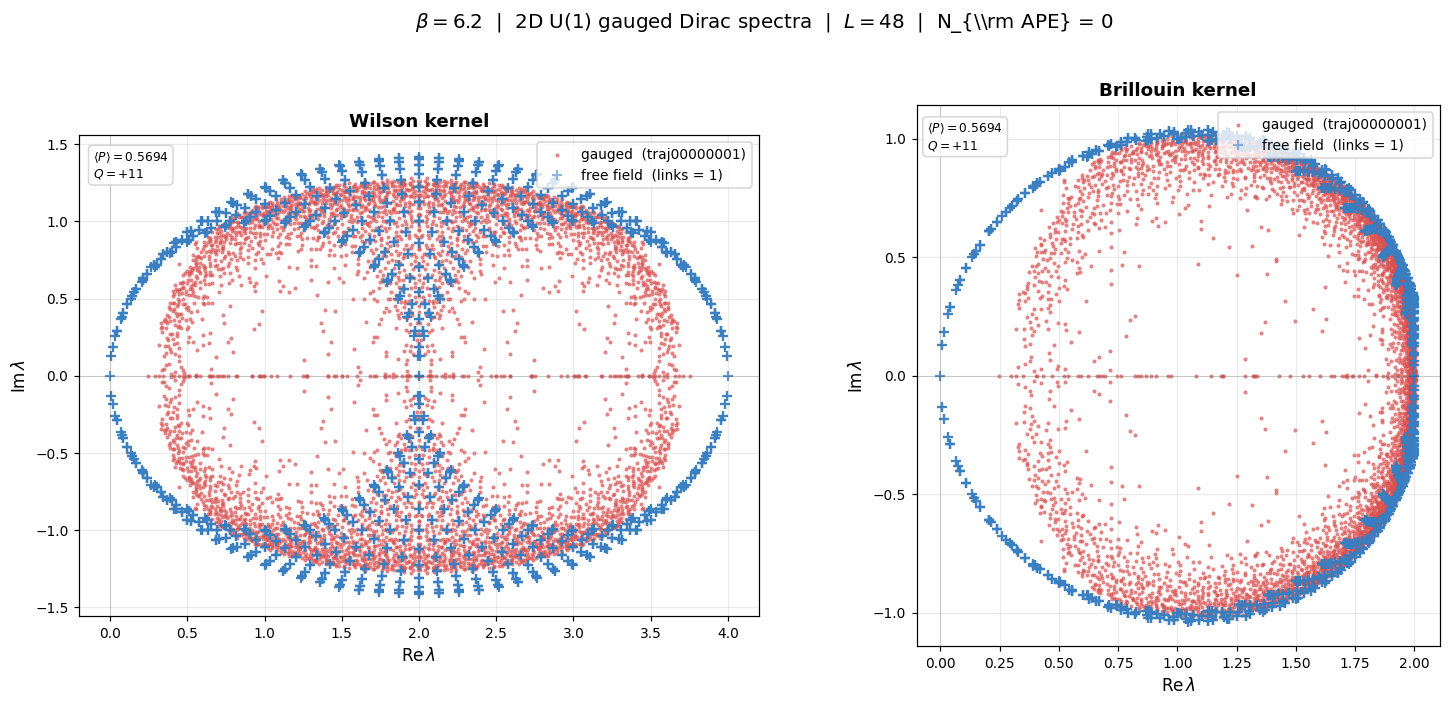

In [4]:
KERNELS = {
    "Wilson": ("std", "std"),  # (derivative key, laplacian key)
    "Brillouin": ("iso", "bri"),
}

cfg0 = configs[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

for ax, (name, (der, lap)) in zip(axes, KERNELS.items()):

    # gauged spectrum on the first configuration
    eig = gauged_spectrum(lap, der, cfg0, n_ape=N_APE)
    ax.scatter(
        eig.real,
        eig.imag,
        s=7,
        c="#d94f4f",
        alpha=0.70,
        linewidths=0,
        label=f"gauged  ({cfg0.traj})",
    )

    # free-field branches for reference
    free = eigenvalues_from_matrix(lap, der, d=DIM, L=L)
    ax.plot(
        free.real,
        free.imag,
        "+",
        ms=7,
        c="#3a7fc1",
        mew=1.4,
        alpha=0.55,
        label="free field  (links = 1)",
    )

    # axes decoration
    ax.axhline(0, color="k", lw=0.5, alpha=0.20)
    ax.axvline(0, color="k", lw=0.5, alpha=0.20)
    ax.set_xlabel(r"$\mathrm{Re}\,\lambda$", fontsize=11)
    ax.set_ylabel(r"$\mathrm{Im}\,\lambda$", fontsize=11)
    ax.set_title(name + " kernel", fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper right")

    # metadata annotation
    plaq_val = cfg0.metadata["plaquette"]
    topo_val = int(round(cfg0.metadata["topo"]))
    ax.text(
        0.02,
        0.97,
        f"$\\langle P \\rangle = {plaq_val:.4f}$\n$Q = {topo_val:+d}$",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.80, ec="#cccccc"),
    )

fig.suptitle(
    rf"$\beta = {BETA}$  |  2D U(1) gauged Dirac spectra  |  $L = {L}$  |  "
    rf"N_{{\\rm APE}} = {N_APE}",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. Spectral cloud — ensemble

Stacking eigenvalues from several configurations fills in the spectral region. Note that:
- **Wilson** has branches at Re λ ≈ 0, 2, 4 (and higher, cut off here), with alternating chirality.
- **Brillouin** condenses all unphysical modes near Re λ ≈ 2, leaving a clear gap around the physical branch.

The Brillouin operator's "cleaner" spectrum is one reason it makes a better overlap kernel: fewer rational-approximation poles are needed to project the sign function.

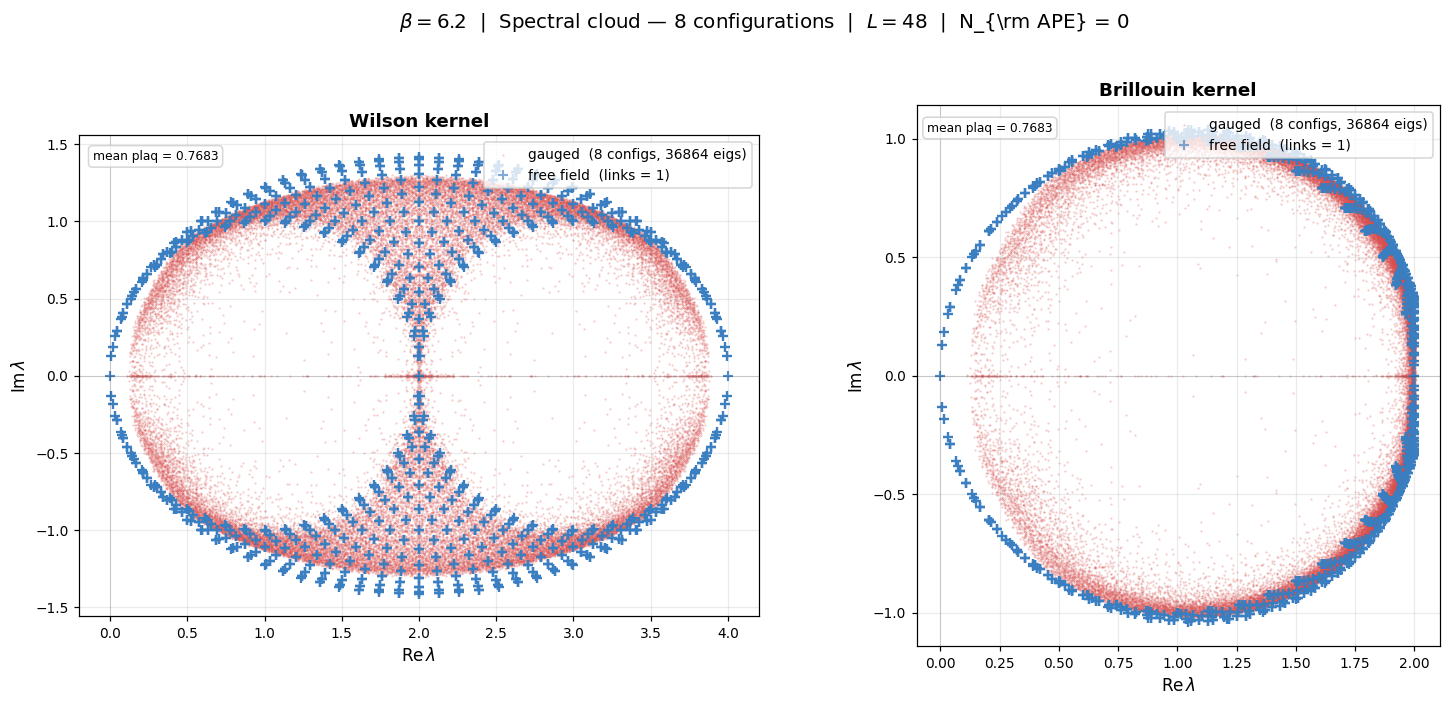

In [5]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6.5))

for ax, (name, (der, lap)) in zip(axes2, KERNELS.items()):

    all_eigs = np.concatenate(
        [gauged_spectrum(lap, der, c, n_ape=N_APE) for c in configs]
    )
    free = eigenvalues_from_matrix(lap, der, d=DIM, L=L)

    ax.scatter(
        all_eigs.real,
        all_eigs.imag,
        s=2,
        c="#d94f4f",
        alpha=0.30,
        linewidths=0,
        label=f"gauged  ({len(configs)} configs, {len(all_eigs)} eigs)",
    )
    ax.plot(
        free.real,
        free.imag,
        "+",
        ms=7,
        c="#3a7fc1",
        mew=1.4,
        alpha=0.65,
        label="free field  (links = 1)",
    )

    ax.axhline(0, color="k", lw=0.5, alpha=0.20)
    ax.axvline(0, color="k", lw=0.5, alpha=0.20)
    ax.set_xlabel(r"$\mathrm{Re}\,\lambda$", fontsize=11)
    ax.set_ylabel(r"$\mathrm{Im}\,\lambda$", fontsize=11)
    ax.set_title(name + " kernel", fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper right")

    ax.text(
        0.02,
        0.97,
        f"mean plaq = {df['plaquette'].mean():.4f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.80, ec="#cccccc"),
    )

fig2.suptitle(
    rf"$\beta = {BETA}$  |  Spectral cloud — {len(configs)} configurations  |  "
    rf"$L = {L}$  |  N_{{\rm APE}} = {N_APE}",
    fontsize=13,
)
fig2.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 5. Notes and next steps

**Varying the smearing level.**  
Set `N_APE = 1, 2, 3` in §1 and rerun. APE smearing smooths the gauge background, tightening the spectral branches and reducing the additive mass shift — a key pre-processing step for overlap-kernel studies.

**Varying β.**  
Generate a second ensemble at β = 2.0 (smoother field, larger plaquette) and compare the cloud width; this is the empirical input for the M4 σ(β) fit.

**4D extension.**  
The same API works for 4D configs once a 4D U(1) generator is available; only the reader's `dim` attribute changes. The code in this notebook is already dimension-agnostic (it reads `DIM = configs[0].dim`).

**Overlap spectra (M4).**  
The next milestone will pass the gauged kernel spectrum through the overlap projection z → (ρ + (ρ − m/2)(z − ρ)/|z − ρ|) and compare with Kenney–Laub sign-function approximants.